# Setup, załadowanie bibliotek i obrazów

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imgA = cv2.imread('A.bmp')
imgB = cv2.imread('B.bmp')
imgC = cv2.imread('C.bmp')
imageBin1 = cv2.imread('binary1.bmp')
imageBin3 = cv2.imread('binary3.bmp')
imgText = cv2.imread('text1.bmp')


# Zadanie 1

## Zadanie 1.a - Binaryzacja obrazu z ustalonym progiem

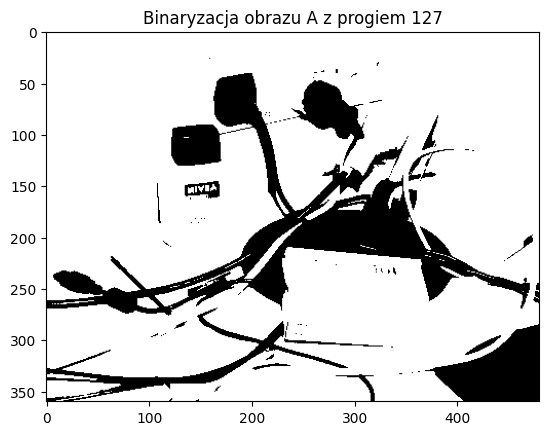

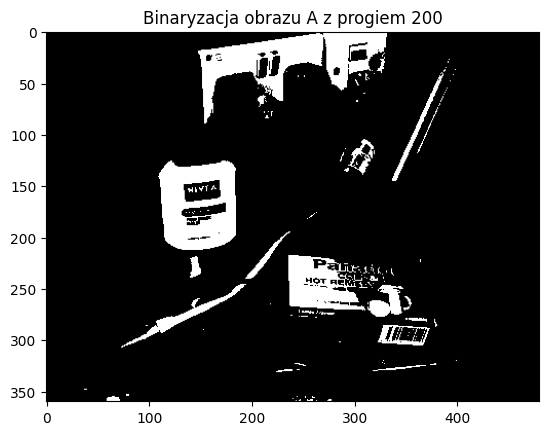

In [22]:
def binaryzacjaProgiem(img, prog):
    """Funkcja binaryzująca obraz z ustalonym progiem.
    Args:
        img: obraz MONOCHROMATYCZNY do binaryzacji 
        prog: próg binaryzacji"""
    x,y,_ = img.shape
    binarizedImg = np.zeros((x,y,3), dtype=np.uint8)
    plt.show()
    for i in range(x):
        for j in range(y):
            if img[i][j][0] < prog:
                binarizedImg[i][j] = [0,0,0]
            else:
                binarizedImg[i][j] = [255,255,255]

    return binarizedImg

## Zadanie 1.a - Binaryzacja obrazu z ustalonym progiem
binarizedImgA = binaryzacjaProgiem(imgA, 127)

plt.imshow(binaryzacjaProgiem(imgA, 127))
plt.title('Binaryzacja obrazu A z progiem 127')
plt.show()

plt.imshow(binaryzacjaProgiem(imgA, 200))
plt.title('Binaryzacja obrazu A z progiem 200')
plt.show()


## Zadanie 1.b - binaryzacja obrazu z progiem wyznaczonym metodą Otsu

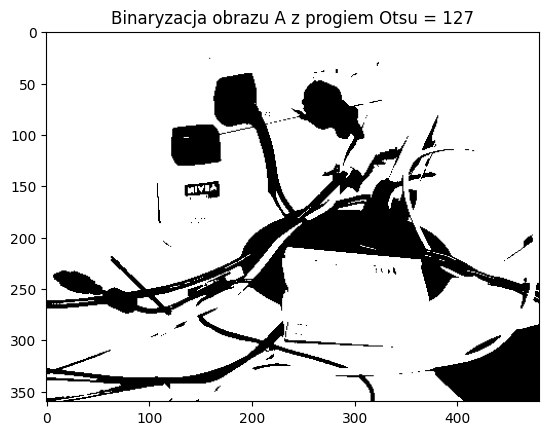

In [24]:
def otsuThreshold(img):
    x,y,z = img.shape
    imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([imgGray], [0], None, [256], [0, 256])
    total = x * y
    sumB = 0
    wB = 0
    maximum = 0.0
    sum1 = np.dot(np.arange(256), hist.flatten())
    for i in range(256):
        wB += hist[i]
        if wB == 0:
            continue
        wF = total - wB
        if wF == 0:
            break
        sumB += i * hist[i]
        mB = sumB / wB
        mF = (sum1 - sumB) / wF
        between = wB * wF * (mB - mF) ** 2
        if between > maximum:
            level = i
            maximum = between
    return level

calculatedThresholdA = otsuThreshold(imgA)
binarizedImgA_Otsu = binaryzacjaProgiem(imgA, calculatedThresholdA)

plt.imshow(binarizedImgA_Otsu)
plt.title('Binaryzacja obrazu A z progiem Otsu = ' + str(calculatedThresholdA))
plt.show()

## Zadanie 1.c

# Zadanie 2